## 1.Business problem 

* There is historical data of insurance claim cases (around 1,300+ cases).
* Each case involves bodily injury insurance claims from a specific region.
* Some claimants hire an attorney{lawyer}, while others do not.
* Hiring an attorney usually increases the settlement amount, which affects:
 1.  The cost to the insurance company
 2. The profitability of the insurer
* The insurance company wants to:
1. Predict the likelihood that a claimant will hire an attorney
2. Understand which types of customers are more likely to hire an attorney
* Based on these insights, the company wants to:
1. Design better insurance policies
2. Target different customer segments differently

## 2.Data collection

### 2.1 Import necessary libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

### 2.2 Import dataset

In [2]:
claimants_data = pd.read_csv(filepath_or_buffer='claimants.csv')
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


### output / Target Variable (Dependent Variable)
ATTORNEY
### Input Variables (Independent Variables)
CASENUM		CLMSEX	CLMINSUR	SEATBELT	CLMAGE	LOSS

**Here we have input and specific output so it is supervised ML**

**Here output is Discrete , so this is classification problem.**

## 3.Data understandin:

### 3.1 perfor initial analysis:

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [6]:
claimants_data.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


## 4.Data preparation:

### 4.1 Data cleaning : Handling null entries

In [7]:
claimants_data = claimants_data.dropna()
claimants_data  # remove missing values NAN

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [8]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### 4.2 Splitting inputs and outputs

during data cleanin we need to apply our common sense

Here we are dropping CASENUM  {nothing but name } based on name we are not going to predeict they will hire attorney .. so dropping this CASENUM column

In [9]:
X = claimants_data.drop(labels = ["CASENUM","ATTORNEY"],axis =1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [10]:
y = claimants_data[["ATTORNEY"]]
y

,ATTORNEY
0,0
1,1
2,1
3,0
4,1
...,...
1334,1
1336,0
1337,1
1338,0


## 5.Model Building:

### 5.1 Train test split

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y , test_size=0.20 ,shuffle=True)
X_train,X_test,y_train,y_test

(      CLMSEX  CLMINSUR  SEATBELT  CLMAGE   LOSS
 316      0.0       1.0       0.0     0.0  0.005
 1151     1.0       1.0       0.0    54.0  4.097
 1135     1.0       1.0       0.0    57.0  3.915
 1083     1.0       1.0       0.0    35.0  1.713
 712      1.0       1.0       0.0     9.0  0.707
 ...      ...       ...       ...     ...    ...
 968      0.0       1.0       0.0    15.0  1.465
 1322     1.0       1.0       0.0     1.0  0.080
 334      0.0       1.0       0.0     8.0  5.830
 41       1.0       0.0       0.0    33.0  8.090
 923      1.0       1.0       0.0    51.0  1.110
 
 [876 rows x 5 columns],
       CLMSEX  CLMINSUR  SEATBELT  CLMAGE   LOSS
 729      0.0       1.0       0.0    11.0  0.500
 1002     1.0       1.0       0.0    15.0  1.766
 860      1.0       0.0       0.0    55.0  1.769
 306      1.0       1.0       0.0     5.0  4.058
 351      1.0       1.0       0.0    53.0  7.549
 ...      ...       ...       ...     ...    ...
 95       1.0       1.0       0.0    71.0 

In [12]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
316,0.0,1.0,0.0,0.0,0.005
1151,1.0,1.0,0.0,54.0,4.097
1135,1.0,1.0,0.0,57.0,3.915
1083,1.0,1.0,0.0,35.0,1.713
712,1.0,1.0,0.0,9.0,0.707
...,...,...,...,...,...
968,0.0,1.0,0.0,15.0,1.465
1322,1.0,1.0,0.0,1.0,0.080
334,0.0,1.0,0.0,8.0,5.830
41,1.0,0.0,0.0,33.0,8.090


In [13]:
logistic_model = LogisticRegression()
logistic_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 6.Model Training:

In [14]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 7.Model Testing:

y_pred = logistic_model.predict(X)
y_pred

#### Training data output: 80%

In [15]:
y_train_pred = logistic_model.predict(X_train)
y_train_pred

array([1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,

#### Testing data output: 20%

In [16]:
y_test_pred = logistic_model.predict(X_test)
y_test_pred

array([1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1])

In [17]:
###claimants_data["predicted_output"] = logistic_model.predict(X)
###claimants_data

## 8.Model evaluation

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score,recall_score, f1_score,roc_auc_score,roc_curve

### 8.1 Training data Evaluation Metrics

#### classification report

In [19]:
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       0.75      0.66      0.70       448
           1       0.68      0.77      0.73       428

    accuracy                           0.71       876
   macro avg       0.72      0.72      0.71       876
weighted avg       0.72      0.71      0.71       876



#### 1.confusion Matrix:

In [20]:
print(confusion_matrix(y_train,y_train_pred))

[[296 152]
 [ 98 330]]


#### 2.Accuracy score

In [21]:
print(accuracy_score(y_train,y_train_pred))

0.7146118721461188


#### 3.Precision

In [22]:
print(precision_score(y_train,y_train_pred))

0.6846473029045643


#### 4.Recall

In [23]:
print(recall_score(y_train,y_train_pred))

0.7710280373831776


#### 5. F1 score:

In [35]:
print(f1_score(y_train,y_train_pred))

0.7252747252747253


#### 6.ROC CURVE -- Receiver operating characterisitics

0.7158711615487316


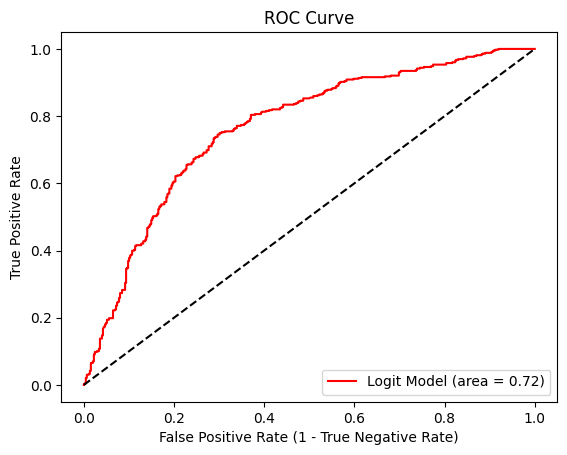

In [41]:
# Calculate False Positive Rate, True Positive Rate and Thresholds
fpr, tpr, thresholds = roc_curve(y_train, logistic_model.predict_proba(X_train)[:, 1])

# Calculate AUC Score
auc = roc_auc_score(y_train, y_train_pred)
print(auc)

# Plot ROC Curve
plt.plot(fpr, tpr, color='red', label='Logit Model (area = %0.2f)' % auc)

# Plot Random Classifier Line
plt.plot([0, 1], [0, 1], 'k--')

# X-axis Label
plt.xlabel('False Positive Rate (1 - True Negative Rate)')

# Y-axis Label
plt.ylabel('True Positive Rate')

# Title
plt.title('ROC Curve')

# Show Legend
plt.legend(loc='lower right')

# Display Graph
plt.show()

### 8.2 Testing data Evaluation Metrics

#### classification report

In [24]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.57      0.66       130
           1       0.56      0.79      0.65        90

    accuracy                           0.66       220
   macro avg       0.68      0.68      0.66       220
weighted avg       0.70      0.66      0.66       220



#### 1.confusion Matrix:

In [25]:
print(confusion_matrix(y_test,y_test_pred))

[[74 56]
 [19 71]]


#### 2.Accuracy score

In [26]:
print(accuracy_score(y_test,y_test_pred))

0.6590909090909091


#### 3.Precision

In [27]:
print(precision_score(y_test,y_test_pred))

0.5590551181102362


#### 4.Recall 

In [28]:
print(recall_score(y_test,y_test_pred))

0.7888888888888889


#### 5. F1 score:

In [36]:
print(f1_score(y_test,y_test_pred))

0.6543778801843319


#### 6.ROC CURVE -- Receiver operating characterisitics

0.679059829059829


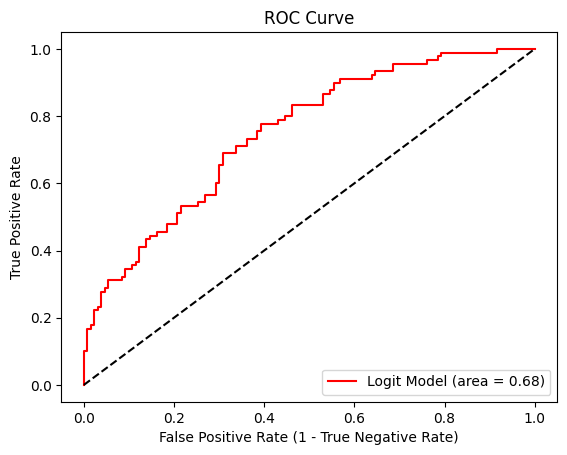

In [44]:
# Calculate False Positive Rate, True Positive Rate and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:, 1])

# Calculate AUC Score
auc = roc_auc_score(y_test, y_test_pred)
print(auc)

# Plot ROC Curve
plt.plot(fpr, tpr, color='red', label='Logit Model (area = %0.2f)' % auc)

# Plot Random Classifier Line
plt.plot([0, 1], [0, 1], 'k--')

# X-axis Label
plt.xlabel('False Positive Rate (1 - True Negative Rate)')

# Y-axis Label
plt.ylabel('True Positive Rate')

# Title
plt.title('ROC Curve')

# Show Legend
plt.legend(loc='lower right')

# Display Graph
plt.show()

## 9.Model deployment:

In [29]:
from pickle import dump

In [30]:
dump(obj=logistic_model,file= open(file=("claimaints.pkl"),mode ="wb"))

In [31]:
from pickle import load

In [32]:
logistic_intelligence_pickle_load = load(file = open(file="claimaints.pkl",mode="rb"))
logistic_intelligence_pickle_load

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
logistic_intelligence_pickle_load.predict(X)

array([0, 1, 1, ..., 1, 0, 1], shape=(1096,))